<a href="https://colab.research.google.com/github/MoriartyPuth/Khmer-Character-Classification/blob/main/Khmer_Character_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
prediction_string = ''.join(map(str, pred_classes))
file_name = 'firstname_lastname.txt'
with open(file_name, 'w') as f:
    f.write(prediction_string)
from google.colab import files
files.download(file_name)
print(f'File created with {len(prediction_string)} digits.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File created with 13897 digits.


In [ ]:
# Please upload kh_char_test_no_label.csv
from google.colab import files
uploaded = files.upload()

import os
if os.path.exists('kh_char_test_no_label.csv'):
    print('Successfully uploaded kh_char_test_no_label.csv. You can now run the training cell below.')
else:
    print('Test file not found. Please ensure the filename is exactly kh_char_test_no_label.csv')

Saving kh_char_test_no_label.zip to kh_char_test_no_label.zip
Test file not found. Please ensure the filename is exactly kh_char_test_no_label.csv


In [ ]:
!unzip -o kh_char_test_no_label.zip
import os
if os.path.exists('kh_char_test_no_label.csv'):
    print('Successfully extracted kh_char_test_no_label.csv')
else:
    print('kh_char_test_no_label.csv not found in the zip file.')

Archive:  kh_char_test_no_label.zip
  inflating: kh_char_test_no_label.csv  
Successfully extracted kh_char_test_no_label.csv


In [ ]:
!unzip -o kh_char_train.zip
import os
if os.path.exists('kh_char_train.csv'):
    print('Successfully extracted kh_char_train.csv')
else:
    print('kh_char_train.csv not found in the zip file.')

Archive:  kh_char_train.zip
  inflating: kh_char_train.csv       
Successfully extracted kh_char_train.csv


In [ ]:
def read_train_data(path):
    data = pd.read_csv(path, keep_default_na=False)
    x = data.iloc[:, 1:].to_numpy(dtype=np.float32)
    labels = data.iloc[:, 0].astype(str).tolist()
    return x, labels

def read_test_data(path):
    data = pd.read_csv(path, keep_default_na=False)
    x = data.iloc[:, 0:].to_numpy(dtype=np.float32)
    return x

In [ ]:
# This cell will now run correctly once the files are uploaded
x, labels = read_train_data('kh_char_train.csv')
x_test = read_test_data('kh_char_test_no_label.csv')

label_map = {'CHHO': 0, 'TA': 1, 'NGO': 2, 'KO': 3, 'KHA': 4, 'CHA': 5, 'NA': 6, 'DA': 7, 'CHHA': 8, 'KHO': 9}
y = np.array([label_map[label] for label in labels])

x = (x / 255.0).reshape((-1, 48, 48, 1))
x_test = (x_test / 255.0).reshape((-1, 48, 48, 1))
y_cat = to_categorical(y, num_classes=10)

x_train, x_val, y_train, y_val = train_test_split(x, y_cat, test_size=0.2, random_state=42, stratify=y)
print('Data loaded successfully.')

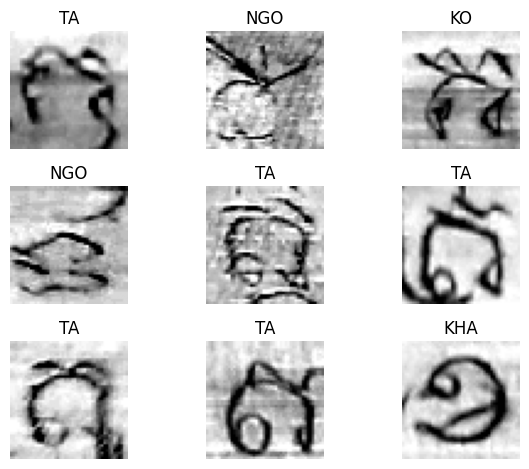

In [ ]:
# Show sample images
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis('off')
    plt.title(labels[i])
    plt.imshow(x[i].reshape((48, 48)), cmap='gray')

plt.tight_layout()
plt.show()

In [ ]:
# Create the labels mapping
label_map = {
    'CHHO': 0,
    'TA': 1,
    'NGO': 2,
    'KO': 3,
    'KHA': 4,
    'CHA': 5,
    'NA': 6,
    'DA': 7,
    'CHHA': 8,
    'KHO': 9
}

y = np.array([label_map[label] for label in labels])

print("First 10 labels:", labels[:10])
print("First 10 numeric labels:", y[:10])

First 10 labels: ['TA', 'NGO', 'KO', 'NGO', 'TA', 'TA', 'TA', 'TA', 'KHA', 'TA']
First 10 numeric labels: [1 2 3 2 1 1 1 1 4 1]


In [ ]:
# Normalize and reshape the images
x = x / 255.0
x_test = x_test / 255.0

x = x.reshape((-1, 48, 48, 1))
x_test = x_test.reshape((-1, 48, 48, 1))

print("Reshaped train:", x.shape)
print("Reshaped test:", x_test.shape)

Reshaped train: (17360, 48, 48, 1)
Reshaped test: (13897, 48, 48, 1)


In [ ]:
# Convert labels into one-hot encoding
y_cat = to_categorical(y, num_classes=10)

print("y shape before one-hot:", y.shape)
print("y shape after one-hot:", y_cat.shape)
print("Example one-hot label:", y_cat[0])

y shape before one-hot: (17360,)
y shape after one-hot: (17360, 10)
Example one-hot label: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Split the training data into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

x_train: (13888, 48, 48, 1)
x_val: (3472, 48, 48, 1)
y_train: (13888, 10)
y_val: (3472, 10)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from google.colab import files
import os

def read_train_data(path):
    data = pd.read_csv(path, keep_default_na=False)
    x = data.iloc[:, 1:].to_numpy(dtype=np.float32)
    labels = data.iloc[:, 0].astype(str).tolist()
    return x, labels

def read_test_data(path):
    data = pd.read_csv(path, keep_default_na=False)
    x = data.iloc[:, 0:].to_numpy(dtype=np.float32)
    return x

try:
    train_file = 'kh_char_train.csv'
    test_file = 'kh_char_test_no_label.csv'

    if not os.path.exists(train_file) or not os.path.exists(test_file):
        raise FileNotFoundError('CSV files not found. Please ensure unzip cells were run successfully.')

    print('Loading and preprocessing data...')
    x_raw, labels = read_train_data(train_file)
    x_test_raw = read_test_data(test_file)

    label_map = {'CHHO': 0, 'TA': 1, 'NGO': 2, 'KO': 3, 'KHA': 4, 'CHA': 5, 'NA': 6, 'DA': 7, 'CHHA': 8, 'KHO': 9}
    y = np.array([label_map[l] for l in labels])

    x = (x_raw / 255.0).reshape((-1, 48, 48, 1))
    x_test = (x_test_raw / 255.0).reshape((-1, 48, 48, 1))
    y_cat = to_categorical(y, num_classes=10)

    x_train, x_val, y_train, y_val = train_test_split(x, y_cat, test_size=0.2, random_state=42, stratify=y)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print('Training model (approx 12 epochs)...')
    model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=12, batch_size=64,
              callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=1)

    print('Generating predictions...')
    pred_classes = np.argmax(model.predict(x_test), axis=1)
    prediction_string = ''.join(map(str, pred_classes))

    print(f'First 10 characters of prediction: {prediction_string[:10]}')

    file_name = 'firstname_lastname.txt'
    with open(file_name, 'w') as f:
        f.write(prediction_string)

    print(f'Success! File {file_name} created with {len(prediction_string)} digits.')
    files.download(file_name)

except Exception as e:
    print(f'An error occurred: {e}')

Loading and preprocessing data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model (approx 12 epochs)...
Epoch 1/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 104s 466ms/step - accuracy: 0.8159 - loss: 0.6328 - val_accuracy: 0.1901 - val_loss: 8.6024
Epoch 2/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 465ms/step - accuracy: 0.9167 - loss: 0.2230 - val_accuracy: 0.9070 - val_loss: 0.2692
Epoch 3/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 467ms/step - accuracy: 0.9417 - loss: 0.1609 - val_accuracy: 0.9453 - val_loss: 0.1676
Epoch 4/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 140s 458ms/step - accuracy: 0.9541 - loss: 0.1320 - val_accuracy: 0.9358 - val_loss: 0.1918
Epoch 5/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 146s 478ms/step - accuracy: 0.9631 - loss: 0.1074 - val_accuracy: 0.9522 - val_loss: 0.1544
Epoch 6/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 144s 488ms/step - accuracy: 0.9664 - loss: 0.0936 - val_accuracy: 0.9559 - val_loss: 0.1544
Epoch 7/12
217/217 ━━━━━━━━━━━━━━━━━━━━ 104s 481ms/step - accuracy: 0.9743 - loss: 0.0723 - val_accuracy: 0.9605 - val_loss: 0.1425
Epoch 8/12
217/217 ━━━━━━━━━━━━━━━━━━━━

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Set training callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=15, batch_size=64, callbacks=[early_stop, reduce_lr])

Epoch 1/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 105s 484ms/step - accuracy: 0.9721 - loss: 0.0744 - val_accuracy: 0.9303 - val_loss: 0.1963 - learning_rate: 0.0010
Epoch 2/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 142s 484ms/step - accuracy: 0.9778 - loss: 0.0636 - val_accuracy: 0.9531 - val_loss: 0.1694 - learning_rate: 0.0010
Epoch 3/15
122/217 ━━━━━━━━━━━━━━━━━━━━ 43s 453ms/step - accuracy: 0.9830 - loss: 0.0451

KeyboardInterrupt: 

In [ ]:
# Evaluate the model
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

Validation Loss: 0.14736858010292053
Validation Accuracy: 0.9576612710952759


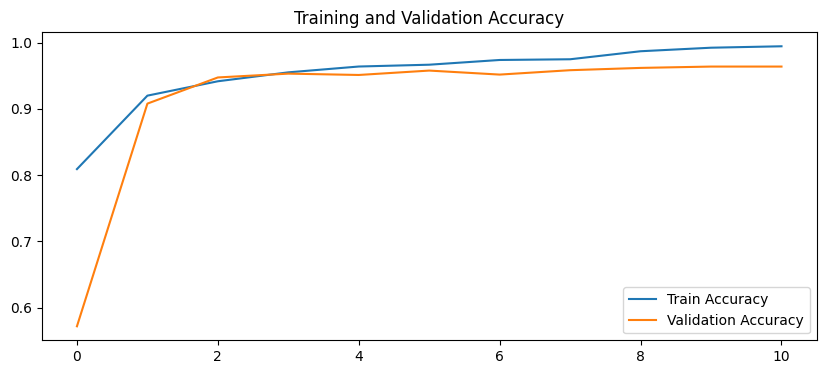

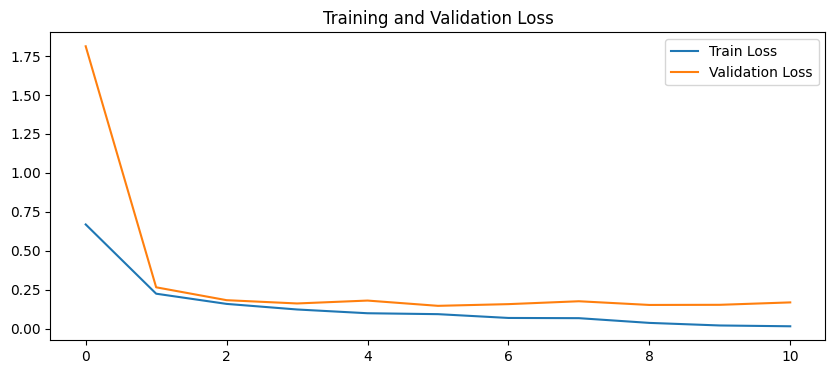

In [ ]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Generate predictions and save the file
pred_probs = model.predict(x_test)
pred_classes = np.argmax(pred_probs, axis=1)

prediction_string = ''.join(map(str, pred_classes))

file_name = 'firstname_lastname.txt'
with open(file_name, 'w') as f:
    f.write(prediction_string)

print(f'File {file_name} created successfully.')
print(f'Total digits in file: {len(prediction_string)}')

from google.colab import files
files.download(file_name)